# Comparação técnica final dos modelos

**Etapa:** síntese da base de ouro

Reunimos desempenho, baseline, previsões e interpretação técnica sem transformar esta etapa em relatório.

**Entrada:** métricas, previsões e comparação com persistência  
**Resultado principal:** ranking final congelado dos quatro modelos


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Comparação técnica e previsões

,dataset,model,split,n_forecasts,mae,rank_gold,baseline_persistence_mae,mae_difference_vs_persistence,improvement_pct_vs_persistence,result_interpretation
0,gold,Holt_Winters,test_final,296,11.533090,1,11.637669,-0.104579,0.898622,superou a persistência no teste
1,gold,SARIMAX,test_final,296,11.598841,2,11.637669,-0.038828,0.333639,superou a persistência no teste
2,gold,PLS_Regression,test_final,296,11.600212,3,11.637669,-0.037457,0.321862,superou a persistência no teste
3,gold,Random_Forest,test_final,296,14.282618,4,11.637669,2.644949,-22.727478,não superou a persistência no teste


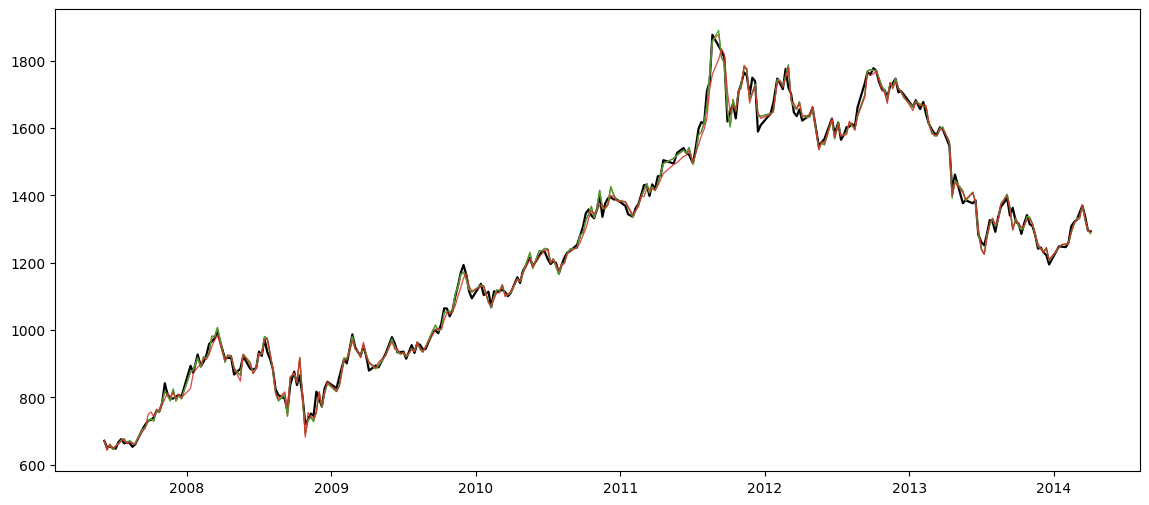

In [3]:
protocol = load_protocol(require_data_decisions=True)
predictions = pd.read_csv(OUT / "predictions.csv", parse_dates=["target_date"])
metrics = pd.read_csv(OUT / "metrics.csv")
comparison = pd.read_csv(OUT / "model_comparison_vs_baseline.csv")

expected = {"SARIMAX", "Holt_Winters", "Random_Forest", "PLS_Regression"}
assert set(predictions["model"]) == expected == set(metrics["model"])

origin_sets = {
    model: tuple(group.sort_values("target_date")["forecast_origin"])
    for model, group in predictions.groupby("model")
}
assert len(set(origin_sets.values())) == 1
assert np.isfinite(predictions[["y_true", "y_pred", "residual"]]).all().all()
assert np.allclose(
    predictions["residual"],
    predictions["y_true"] - predictions["y_pred"],
)

technical = comparison.copy()
technical["result_interpretation"] = np.where(
    technical["improvement_pct_vs_persistence"] > 0,
    "superou a persistência no teste",
    "não superou a persistência no teste",
)
technical.to_csv(OUT / "technical_model_comparison.csv", index=False)
display(technical.sort_values("rank_gold"))

wide = predictions.pivot(
    index="target_date",
    columns="model",
    values="y_pred",
)
actual = (
    predictions.groupby("target_date", as_index=True)["y_true"]
    .first()
    .sort_index()
)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(actual.index, actual.values, color="black", linewidth=1.6, label="real")
for model in metrics.sort_values("rank_gold")["model"]:
    ax.plot(wide.index, wide[model], linewidth=0.9, alpha=0.85, label=model)


In [4]:
ax.set_title("Previsões congeladas no teste final")
ax.set_ylabel("USD por onça fina")
ax.legend(ncol=3)
plt.tight_layout()
plt.savefig(OUT / "model_predictions_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    "Holt-Winters, SARIMAX e PLS ficaram próximos da persistência. "
    "Diferenças pequenas de MAE não devem ser tratadas como superioridade ampla."
)


Holt-Winters, SARIMAX e PLS ficaram próximos da persistência. Diferenças pequenas de MAE não devem ser tratadas como superioridade ampla.


## 3. Tabela final com o baseline

In [5]:
# FINAL_GOLD_MODEL_COMPARISON
# Baseline é referência diagnóstica e permanece fora do ranking oficial.

baseline_mae = float(comparison["baseline_persistence_mae"].iloc[0])
best_mae = float(comparison["mae"].min())

gold_summary = comparison[[
    "dataset", "model", "split", "n_forecasts", "mae", "rank_gold"
]].copy()
gold_summary = gold_summary.rename(columns={"rank_gold": "official_rank"})
gold_summary["reference_type"] = "modelo oficial"

baseline_row = pd.DataFrame(
    [
        {
            "dataset": "gold",
            "model": "Baseline_Persistencia",
            "split": "test_final",
            "n_forecasts": 296,
            "mae": baseline_mae,
            "official_rank": np.nan,
            "reference_type": "referência diagnóstica; fora do ranking oficial",
        }
    ]
)
gold_summary = pd.concat([gold_summary, baseline_row], ignore_index=True)
gold_summary["mae_minus_baseline"] = gold_summary["mae"] - baseline_mae
gold_summary["absolute_difference_vs_baseline"] = (
    gold_summary["mae"] - baseline_mae
).abs()
gold_summary["improvement_pct_vs_baseline"] = (
    (baseline_mae - gold_summary["mae"]) / baseline_mae * 100
)
gold_summary["mae_minus_best_model"] = gold_summary["mae"] - best_mae


In [6]:
gold_summary["interpretation"] = gold_summary["model"].map(
    {
        "Holt_Winters": "menor MAE; ganho pequeno sobre a persistência",
        "SARIMAX": "praticamente empatado com PLS e próximo da persistência",
        "PLS_Regression": "praticamente empatado com SARIMAX e próximo da persistência",
        "Random_Forest": "pior que a persistência; limitação de extrapolação ajuda a explicar o resultado",
        "Baseline_Persistencia": "referência diagnóstica comparável nas mesmas 296 origens",
    }
)

gold_summary.to_csv(OUT / "gold_model_comparison_summary.csv", index=False)
display(gold_summary.sort_values("mae"))

,dataset,model,split,n_forecasts,mae,official_rank,reference_type,mae_minus_baseline,absolute_difference_vs_baseline,improvement_pct_vs_baseline,mae_minus_best_model,interpretation
0,gold,Holt_Winters,test_final,296,11.533090,1.0,modelo oficial,-0.104579,0.104579,0.898622,0.000000,menor MAE; ganho pequeno sobre a persistência
1,gold,SARIMAX,test_final,296,11.598841,2.0,modelo oficial,-0.038828,0.038828,0.333639,0.065751,praticamente empatado com PLS e próximo da per...
2,gold,PLS_Regression,test_final,296,11.600212,3.0,modelo oficial,-0.037457,0.037457,0.321862,0.067121,praticamente empatado com SARIMAX e próximo da...
4,gold,Baseline_Persistencia,test_final,296,11.637669,NaN,referência diagnóstica; fora do ranking oficial,0.000000,0.000000,0.000000,0.104579,referência diagnóstica comparável nas mesmas 2...
3,gold,Random_Forest,test_final,296,14.282618,4.0,modelo oficial,2.644949,2.644949,-22.727478,2.749527,pior que a persistência; limitação de extrapol...


## Interpretação

Holt-Winters teve o menor MAE. SARIMAX e PLS ficaram praticamente empatados. O RF teve dificuldade de extrapolação, mas sua implementação foi auditada e está correta.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/gold_model_comparison_summary.csv`
- `outputs/technical_model_comparison.csv`
- `outputs/model_predictions_comparison.png`